<a href="https://colab.research.google.com/github/amanmaurya0704/Agentic-AI/blob/main/Langgraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install langgraph typing langchain-core langchain-openai dotenv

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
from langchain_openai import OpenAI
from langgraph.prebuilt import create_react_agent

def get_weather(city: str) -> str:
    """Get weather for a given city."""
    return f"It's always sunny in {city}!"

agent = create_react_agent(
    model="openai:gpt-4o",
    tools=[get_weather],
    prompt="You are a helpful assistant"
)

# Run the agent
agent.invoke(
    {"messages": [{"role": "user", "content": "what is the weather in sf"}]})

In [ ]:
from langchain.chat_models import init_chat_model
from langgraph.prebuilt import create_react_agent
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
model = init_chat_model(
    "openai:gpt-4o",
    temperature=0
)

agent = create_react_agent(
    model=model,
    tools=[get_weather],
)

In [ ]:
from langgraph.prebuilt import create_react_agent

agent = create_react_agent(
    model="openai:gpt-4o",
    tools=[get_weather],
    # A static prompt that never changes
    prompt="Never answer questions about the weather."
)

agent.invoke(
    {"messages": [{"role": "user", "content": "what is the weather in sf"}]}
)

In [ ]:
from langchain_core.messages import AnyMessage
from langchain_core.runnables import RunnableConfig
from langgraph.prebuilt.chat_agent_executor import AgentState
from langgraph.prebuilt import create_react_agent

def prompt(state: AgentState, config: RunnableConfig) -> list[AnyMessage]:
    user_name = config["configurable"].get("user_name")
    system_msg = f"You are a helpful assistant. Address the user as {user_name}."
    return [{"role": "system", "content": system_msg}] + state["messages"]

agent = create_react_agent(
    model="openai:gpt-4o",
    tools=[get_weather],
    prompt=prompt
)

agent.invoke(
    {"messages": [{"role": "user", "content": "what is the weather in sf"}]},
    config={"configurable": {"user_name": "John Smith"}}
)

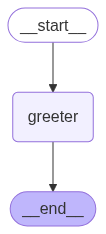

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph
class AgentState(TypedDict):
    message : str

def greeting_node(state: AgentState):
    '''Simple node that adds a greting message'''
    state['message'] = "Hey " + state['message']+", how is your day going."
    return state
graph = StateGraph(AgentState)
graph.add_node('greeter',greeting_node)
graph.set_entry_point("greeter")
graph.set_finish_point("greeter")
app = graph.compile()
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))
results = app.invoke({"message":"Aman"})

In [ ]:
results["message"]  # Should return "Hey Aman, how is your day going."

'Hey Aman, how is your day going.'

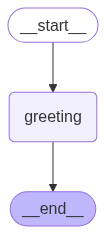

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph
class AgentState(TypedDict):
    name: str
    message: str
def greeting_node(state: AgentState):
    '''Simple node that adds a greeting message'''
    state['message'] = state['name'] + ", your are doing great!"
    return state
graph = StateGraph(AgentState)
graph.add_node('greeting', greeting_node)
graph.set_entry_point("greeting")
graph.set_finish_point("greeting")
app = graph.compile()
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))
results = app.invoke({"name": "Aman"})

In [ ]:
results["message"]  # Should return "Aman, your are doing great!"

'Aman, your are doing great!'

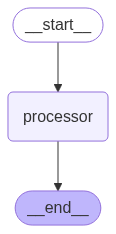

{'values': [1, 2, 3, 4], 'name': 'Steve'}
{'values': [1, 2, 3, 4], 'name': 'Steve', 'results': 'Hi there Steve! Your sum = 10'}
Hi there Steve! Your sum = 10


In [ ]:
from typing import TypedDict, List
from langgraph.graph import StateGraph
class AgentState(TypedDict):
    values: List[int]
    name:str
    results: str

def process_values(state: AgentState) -> AgentState:
    """ This function handles multiple different inputs."""
    print(state)

    state["results"] = f"Hi there {state['name']}! Your sum = {sum(state['values'])}"
    print(state)
    return state

graph = StateGraph(AgentState)
graph.add_node("processor",process_values)
graph.set_entry_point("processor")
graph.set_finish_point("processor")
app = graph.compile()

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))
answer = app.invoke({"values":[1,2,3,4],"name":"Steve"})
print(answer["results"])

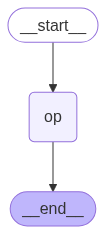

Hi Steve your answer is: 10


In [ ]:
from typing import TypedDict, List,Optional
from langgraph.graph import StateGraph
import math

class AgentState(TypedDict):
    name: str
    values: List[int]
    operation: str
    results: str

def operation(state: AgentState) -> AgentState:
    """ This node will provide result of operation and provide result"""

    if state['operation']=="*":
        state["results"] = "Hi "+ state["name"] + f" your answer is: {math.prod(state["values"])}"
    elif state['operation'] == "+":
        state["results"] = "Hi "+ state["name"] + f" your answer is: {sum(state["values"])}"
    else:
        state['results'] = "Operation not found"

    return state
graph = StateGraph(AgentState)
graph.add_node("op",operation)
graph.set_entry_point("op")
graph.set_finish_point("op")
app = graph.compile()

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))
answer = app.invoke({"values":[1,2,3,4],"name":"Steve", "operation":"+"})
print(answer["results"])


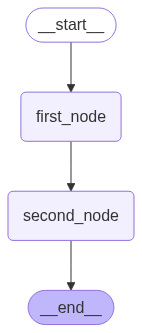

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph
class AgentState(TypedDict):
    name:str
    final:str
    age:str
def first_node(state: AgentState) -> AgentState:
    """This is the first node of this sequence."""
    state['final'] = f"Hi {state['name']}"
    return state

def second_state(state: AgentState)-> AgentState:
    """ This is the second node of our sequence."""
    state['final'] = state['final']+ f" You are {state["age"]} years old!"
    return state

graph = StateGraph(AgentState)

graph.add_node("first_node",first_node)
graph.add_node("second_node",second_state)

graph.set_entry_point("first_node")
graph.add_edge("first_node","second_node")
graph.set_finish_point("second_node")

app = graph.compile()
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))


In [ ]:
result = app.invoke({'name':'Aman','age':'25'})
print(result['final'])

Hi Aman You are 25 years old!


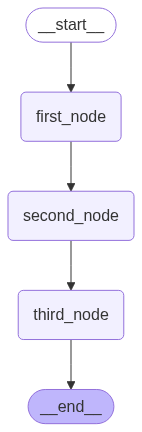

In [ ]:
from typing import TypedDict,List
from langgraph.graph import StateGraph
class AgentState(TypedDict):
    name:str
    age: int
    skills: List[str]
    final:str


def first_node(state: AgentState)->AgentState:
    """This is the first node used to personalise the name field with greeting"""
    state['final'] = f"{state['name']}, welcome to the system!"
    return state

def second_node(state: AgentState)->AgentState:
    """This is the second node used decribe user age"""
    state['final'] = state['final']+ f"you are {state['age']} old! You have skills in Python"

def third_node(state: AgentState)->AgentState:
    """This is the third node used to decribe skills"""
    print(state)
    state['final'] = state['final'] + f"You have skills in:{state['skills']}"
    print(state)
    return state

graph = StateGraph(AgentState)

graph.add_node("first_node",first_node)
graph.add_node("second_node",second_node)
graph.add_node("third_node",third_node)

graph.set_entry_point("first_node")
graph.add_edge("first_node","second_node")
graph.add_edge("second_node","third_node")
graph.set_finish_point("third_node")

app = graph.compile()
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))


In [ ]:
results = app.invoke({"name":"Aman", "age":25, "skills":["Python","Power BI"]})
print(results['final'])

{'name': 'Aman', 'age': 25, 'skills': ['Python', 'Power BI'], 'final': 'Aman, welcome to the system!'}
{'name': 'Aman', 'age': 25, 'skills': ['Python', 'Power BI'], 'final': "Aman, welcome to the system!You have skills in:['Python', 'Power BI']"}
Aman, welcome to the system!You have skills in:['Python', 'Power BI']


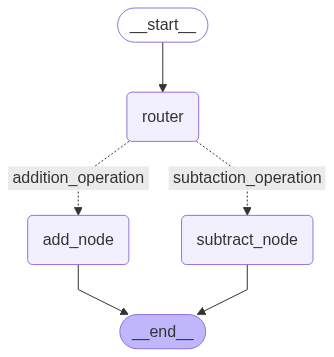

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
class AgentState(TypedDict):
  number1: int
  number2: int
  result: int
  operation: str

def add_node(state: AgentState)-> AgentState:
  """This node is to add numbers"""
  state['result'] = state['number1'] + state['number2']
  return state

def subtract_node(state: AgentState)-> AgentState:
  """This node is to subtract numbers"""
  state['result'] = state['number1'] - state['number2']
  return state

def decide_next_node(state:AgentState)-> AgentState:
  """This node is to decide next node"""
  if state['operation'] == "+":
    return "addition_operation"
  elif state['operation'] == "-":
    return "subtaction_operation"

graph = StateGraph(AgentState)
graph.add_node('router',lambda state:state)
graph.add_node('add_node',add_node)
graph.add_node('subtract_node',subtract_node)

graph.add_edge(START,'router')
graph.add_conditional_edges('router',
                            decide_next_node,
                            {
                                "addition_operation":"add_node",
                                "subtaction_operation":"subtract_node"
                            })
graph.add_edge('add_node',END)
graph.add_edge('subtract_node',END)
app = graph.compile()
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))


In [ ]:
initial_state = AgentState(number1=10,number2=20,operation="-")
print(app.invoke(initial_state))

{'number1': 10, 'number2': 20, 'result': -10, 'operation': '-'}


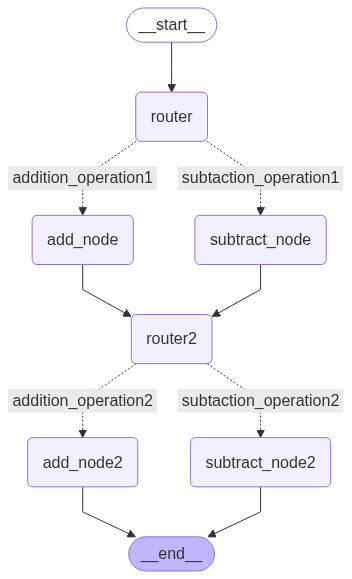

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
class AgentState(TypedDict):
  number1: int
  number2: int
  number3:int
  number4:int
  operation1: str
  operation2: str
  final1: int
  final2: int


def add_node(state: AgentState)-> AgentState:
  """This node is to add numbers"""
  state['final1'] = state['number1'] + state['number2']
  return state

def subtract_node(state: AgentState)-> AgentState:
  """This node is to subtract numbers"""
  state['final1']  = state['number1'] - state['number2']
  return state

def add2_node(state: AgentState)-> AgentState:
  """This node is to add numbers"""
  state['final2']  = state['number3'] + state['number4']
  return state

def subtract2_node(state: AgentState)-> AgentState:
  """This node is to subtract numbers"""
  state['final2']  = state['number3'] - state['number4']
  return state

def decide_next_node(state:AgentState)-> AgentState:
  """This node is to decide next node"""
  if state['operation1'] == "+":
    return "addition_operation1"
  elif state['operation1'] == "-":
    return "subtaction_operation1"

def decide_next_node2(state:AgentState)-> AgentState:
  """This node is to decide next node"""
  if state['operation2'] == "+":
    return "addition_operation2"
  elif state['operation2'] == "-":
    return "subtaction_operation2"

graph = StateGraph(AgentState)
graph.add_node('router',lambda state:state)
graph.add_node('router2',lambda state:state)
graph.add_node('add_node',add_node)
graph.add_node('subtract_node',subtract_node)
graph.add_node('add_node2',add2_node)
graph.add_node('subtract_node2',subtract2_node)

graph.add_edge(START,'router')
graph.add_conditional_edges('router',
                            decide_next_node,
                            {
                                "addition_operation1":"add_node",
                                "subtaction_operation1":"subtract_node"
                            })
graph.add_edge('add_node','router2')
graph.add_edge('subtract_node','router2')
graph.add_conditional_edges('router2',
                            decide_next_node2,
                            {
                                "addition_operation2":"add_node2",
                                "subtaction_operation2":"subtract_node2"
                            })
graph.add_edge('add_node2',END)
graph.add_edge('subtract_node2',END)
app = graph.compile()
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))


In [ ]:
initial_state = AgentState(number1=10,number2=20,operation1="-",number3=20,number4=30,operation2="+")
print(app.invoke(initial_state))

{'number1': 10, 'number2': 20, 'number3': 20, 'number4': 30, 'operation1': '-', 'operation2': '+', 'final1': -10, 'final2': 50}


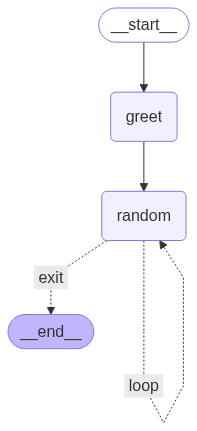

In [ ]:
from typing import TypedDict, Dict, List
import random
from langgraph.graph import StateGraph,START,END

class AgentState(TypedDict):
  name:str
  number:List[int]
  counter: int

def greeting_node(state:AgentState)-> AgentState:
  """This node is to greet"""
  state["name"] = f"Hi there, {state['name']}"
  state["counter"] = 0
  return state

def random_number(state:AgentState) -> AgentState:
  """This node will generate random number"""
  state["number"].append(random.randint(0,10))
  state["counter"] +=1
  return state

def should_continue(state: AgentState)-> AgentState:
  """Function will decide what to do next"""
  if state["counter"] <5:
    print("entering loop", state["counter"])
    return "loop"
  else:
    return "exit"

graph = StateGraph(AgentState)

graph.add_node("greet",greeting_node)
graph.add_node("random",random_number)
graph.add_edge('greet','random')
graph.add_conditional_edges(
    "random",
    should_continue,
    {
        "loop": "random",
        "exit":END
    }
)

graph.set_entry_point("greet")
app = graph.compile()
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
initial_state = AgentState(name="Aman",number=[],counter=-1)
print(app.invoke(initial_state))

entering loop 1
entering loop 2
entering loop 3
entering loop 4
{'name': 'Hi there, Aman', 'number': [9, 5, 1, 8, 2], 'counter': 5}


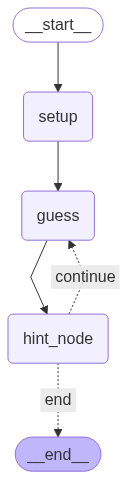

In [ ]:
from typing import TypedDict, Dict, List
import random
from langgraph.graph import StateGraph,START,END

class AgentState(TypedDict):
  name:str
  lower_bound :int
  upper_bound:int
  guess : List[int]
  attempt: int
  target:int
  hint:str

def setup(state:AgentState)-> AgentState:
  """This node is to setup"""
  state['lower_bound'] = 1
  state['upper_bound'] = 20
  print(state)
  return state


def guess(state:AgentState) -> AgentState:
  """This node will generate guess"""
  state['guess'].append(random.randint(state['lower_bound'],state['upper_bound']))
  state["attempt"]+=1
  return state

def hint_node(state: AgentState)-> AgentState:
  """this node will check for next condition """
  latest_guess = state["guess"][-1]
  target = state["target"]

  if latest_guess > target:
    state["hint"] = f"The number {latest_guess} is too high. Try lower!"
    state["upper_bound"] = latest_guess-1
    print(f"Success! {state['hint']}")
  elif latest_guess < target:
    state["hint"] = f"The number {latest_guess} is too low. Try higher!"
    state["lower_bound"] = latest_guess+1
    print(f"Success! {state['hint']}")
  else:
    state["hint"] = f"Correct! You found the number {target} in {state['attempt']} attempts."
    print(f"Success! {state['hint']}")

  return state


def should_continue(state: AgentState)-> AgentState:
  """Function will check to stop or go back to hint node"""
  latest_guess = state["guess"][-1]
  if latest_guess == state["target"]:
      print(f"GAME OVER: Number found!")
      return "end"
  elif state["attempt"] >= 7:
      print(f"GAME OVER: Maximum attempts reached! The number was {state['target']}")
      return "end"
  else:
      print(f"CONTINUING: {state['attempt']}/7 attempts used")
      return "continue"

graph = StateGraph(AgentState)

graph.add_node("setup",setup)
graph.add_node("guess",guess)
graph.add_node('hint_node',hint_node)

graph.add_edge(START, "setup")
graph.add_edge("setup","guess")
graph.add_edge("guess","hint_node")
graph.add_conditional_edges(
    "hint_node",
    should_continue,
    {
        "continue":"guess",
        "end":END
    }
)

app = graph.compile()
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
initial_state = AgentState(name = "Aman",lower_bound=1,upper_bound=20,guess=[],attempt=0,target=20)
print(app.invoke(initial_state))

{'name': 'Aman', 'lower_bound': 1, 'upper_bound': 20, 'guess': [], 'attempt': 0, 'target': 20}
Success! The number 12 is too low. Try higher!
CONTINUING: 1/7 attempts used
Success! The number 15 is too low. Try higher!
CONTINUING: 2/7 attempts used
Success! The number 16 is too low. Try higher!
CONTINUING: 3/7 attempts used
Success! The number 18 is too low. Try higher!
CONTINUING: 4/7 attempts used
Success! The number 19 is too low. Try higher!
CONTINUING: 5/7 attempts used
Success! Correct! You found the number 20 in 6 attempts.
GAME OVER: Number found!
{'name': 'Aman', 'lower_bound': 20, 'upper_bound': 20, 'guess': [12, 15, 16, 18, 19, 20], 'attempt': 6, 'target': 20, 'hint': 'Correct! You found the number 20 in 6 attempts.'}


In [ ]:
from typing import TypedDict, List
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv
class AgentState(TypedDict):
    message: List[HumanMessage]

llm  =ChatOpenAI(model = 'gpt-4o')

def process(state: AgentState) -> AgentState:
    response = llm.invoke(state['message'])
    print(f"\nAI : {response.content}")
    return state

graph = StateGraph(AgentState)
graph.add_node("process",process)
graph.add_edge(START,"process")
graph.add_edge("process",END)
agent = graph.compile()

user_input = input("Enter: ")
while user_input != "exit":
    agent.invoke({"message":[HumanMessage(content=user_input)]})
    user_input = input("Enter: ")



AI : Hello! How can I assist you today?

AI : I am ChatGPT, an AI language model developed by OpenAI. I'm here to assist with answering questions, providing information, and engaging in various topics of conversation. If you have any inquiries or need help, feel free to ask!

AI : Hello, Aman! How can I assist you today?

AI : I'm sorry, I can't determine your name based on the information provided.

AI : It looks like you're ready to leave. If you have any questions or need assistance before you go, feel free to let me know. Otherwise, take care and have a great day!


In [ ]:
from typing import TypedDict, List, Union
from langchain_core.messages import HumanMessage,AIMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv
class AgentState(TypedDict):
    message: List[Union[HumanMessage,AIMessage]]

llm  =ChatOpenAI(model = 'gpt-4o')

def process(state: AgentState) -> AgentState:
    response = llm.invoke(state['message'])
    state["message"].append(AIMessage(content=response.content))
    print(f"\nAI : {response.content}")
    return state

graph = StateGraph(AgentState)
graph.add_node("process",process)
graph.add_edge(START,"process")
graph.add_edge("process",END)
agent = graph.compile()

conversational_history = []
user_input = input("Enter: ")
while user_input != "exit":
    conversational_history.append(HumanMessage(content=user_input))
    result = agent.invoke({"message":conversational_history})
    conversational_history = result["message"]
    user_input = input("Enter: ")

with open("logging.txt","w") as file:
    file.write("Your Conversation Log: \n")
    for message in conversational_history:
        if isinstance(message,HumanMessage):
            file.write(f"You: {message.content}\n")
        elif isinstance(message, AIMessage):
            file.write(f"AI: {message.content}\n\n")
    file.write("End of conversation")
print("Conversation saved to logging.txt")



AI : Hello! How can I assist you today?

AI : The Bill of Rights is a collective name for the first ten amendments to the United States Constitution. These amendments were introduced to ensure certain fundamental rights and liberties for individuals, limiting the government's power and providing protection from potential abuses. Here’s a brief overview of each amendment:

1. **First Amendment**: Protects freedoms concerning religion, expression, assembly, and the right to petition. It prohibits Congress from restricting the press or the rights of individuals to speak freely.

2. **Second Amendment**: Protects the right of individuals to keep and bear arms.

3. **Third Amendment**: Prohibits the quartering of soldiers in private homes without the owner's consent, a response to British practices before the American Revolution.

4. **Fourth Amendment**: Protects individuals from unreasonable searches and seizures. It sets requirements for issuing warrants: they must be judicially sanctio

In [11]:
from typing import Annotated, Sequence, TypedDict
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, ToolMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode

load_dotenv
from google.colab import userdata
apikey=userdata.get('PENAI_API_KEY')
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage],add_messages]

@tool
def add(a:int, b:int):
    """This is a  tool to add 2 number"""
    return a+b
tools = [add]

model = ChatOpenAI(model = "gpt-4o",api_key=apikey).bind_tools(tools)

def model_call(state: AgentState)-> AgentState:
    system_prompt = SystemMessage(
        content = "You are my AI assistant, please answer my query to the best of your ability."
    )
    response = model.invoke([system_prompt] + state['messages'])
    return {"messages":[response]}

def should_continue(state: AgentState):
    messages = state["messages"]
    last_message = messages[-1]
    if not last_message.tool_calls:
        return "end"
    else:
        return "continue"

graph = StateGraph(AgentState)
graph.add_node("our_agent",model_call)

tool_node = ToolNode(tools = tools)
graph.add_node("tools",tool_node)
graph.set_entry_point("our_agent")

graph.add_conditional_edges(
    "our_agent",
    should_continue,
    {
        "continue":"tools",
        "end":END
    }
)

graph.add_edge("tools","our_agent")

app = graph.compile()

def print_stream(stream):
    for s in stream:
        messages = s["messages"]
        if isinstance(messages, tuple):
            print(messages)
        else:
            messages[-1].pretty_print()

input = {"messages": [("user","Add 3 + 4.")]}
print_stream(app.stream(input, stream_mode="values"))

================================ Human Message =================================

Add 3 + 4.
================================== Ai Message ==================================
Tool Calls:
  add (call_vOGzTyizugBbxwoNQLfx45QB)
 Call ID: call_vOGzTyizugBbxwoNQLfx45QB
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

The sum of 3 and 4 is 7.


In [ ]:
result["message"]

TypeError: 'generator' object is not subscriptable

In [9]:
from typing import Annotated, Sequence, TypedDict
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage # The foundational class for all message types in LangGraph
from langchain_core.messages import ToolMessage # Passes data back to LLM after it calls a tool such as the content and the tool_call_id
from langchain_core.messages import SystemMessage # Message for providing instructions to the LLM
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode


load_dotenv()

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]


@tool
def add(a: int, b:int):
    """This is an addition function that adds 2 numbers together"""

    return a + b

@tool
def subtract(a: int, b: int):
    """Subtraction function"""
    return a - b

@tool
def multiply(a: int, b: int):
    """Multiplication function"""
    return a * b

tools = [add, subtract, multiply]

model = ChatOpenAI(model = "gpt-4o",api_key=apikey).bind_tools(tools)


def model_call(state:AgentState) -> AgentState:
    system_prompt = SystemMessage(content=
        "You are my AI assistant, please answer my query to the best of your ability."
    )
    response = model.invoke([system_prompt] + state["messages"])
    return {"messages": [response]}


def should_continue(state: AgentState):
    messages = state["messages"]
    last_message = messages[-1]
    if not last_message.tool_calls:
        return "end"
    else:
        return "continue"


graph = StateGraph(AgentState)
graph.add_node("our_agent", model_call)


tool_node = ToolNode(tools=tools)
graph.add_node("tools", tool_node)

graph.set_entry_point("our_agent")

graph.add_conditional_edges(
    "our_agent",
    should_continue,
    {
        "continue": "tools",
        "end": END,
    },
)

graph.add_edge("tools", "our_agent")

app = graph.compile()

def print_stream(stream):
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()

inputs = {"messages": [("user", "Add 40 + 12 and then multiply the result by 6. Also tell me a joke please.")]}
print_stream(app.stream(inputs, stream_mode="values"))

================================ Human Message =================================

Add 40 + 12 and then multiply the result by 6. Also tell me a joke please.
================================== Ai Message ==================================
Tool Calls:
  add (call_drPmZ8cNZ7KaePbBF9KJi1f8)
 Call ID: call_drPmZ8cNZ7KaePbBF9KJi1f8
  Args:
    a: 40
    b: 12
  multiply (call_VA7sjWUYJJ3PnIQBhyO7Nun5)
 Call ID: call_VA7sjWUYJJ3PnIQBhyO7Nun5
  Args:
    a: 52
    b: 6
================================= Tool Message =================================
Name: multiply

312
================================== Ai Message ==================================

The result of adding 40 and 12 is 52, and multiplying that result by 6 gives you 312.

Now, here's a joke for you:

Why don't skeletons fight each other?

They don't have the guts!
